In [15]:
import scrapy
import pandas as pd
import requests
import geopandas as gpd

In [ ]:
michigan_counties = 'https://services3.arcgis.com/dxRQUfTDNtfqZ301/arcgis/rest/services/County/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson'
response = requests.get(michigan_counties)
data = response.json()  

df = pd.json_normalize(data['features'])
df.head()

In [12]:
geometry = '-85.605,42.275,-85.570,42.305'
params = f'where=1%3D1&geometryType=esriGeometryEnvelope&inSR=4326&geometry={geometry}&outFields=*&returnGeometry=true&f=geojson'
kzoo_base = 'https://gis.kalamazoocity.org/hosting/rest/services/General_Items/Parcel_Layer/FeatureServer/0/query?' 
url = (f'{kzoo_base}{params}') 
response = requests.get(url)
data = response.json()  
df = pd.json_normalize(data['features'])
df.head()

,type,id,geometry.type,geometry.coordinates,properties.OBJECTID,properties.ID,properties.SBC,properties.PIN,properties.created_date,properties.last_edited_user,properties.last_edited_date,properties.Shape__Length,properties.Shape__Area,properties.GlobalID,properties.created_user,properties.Bulk_Trash_Zone,properties.Block_Group
0,Feature,7091,Polygon,"[[[-85.5980158404411, 42.28158289792995], [-85...",7091,7667.0,0298740,06-21-270-003,NaN,SA,1709842016000,349.656456,5546.077255,{367110A2-DB7B-4D5A-8172-FE6A4E4FAE2E},NaN,3rd MONDAY,260770006012
1,Feature,6498,Polygon,"[[[-85.58910757578636, 42.283379261240015], [-...",6498,7024.0,0229600,06-22-160-003,NaN,SA,1709842004000,195.736530,2071.154855,{B15550BD-CDED-4A38-BB5A-663712CE0B7E},NaN,1st WEDNESDAY,260770006015
2,Feature,7162,Polygon,"[[[-85.59156960883216, 42.2814350740147], [-85...",7162,7738.0,0320560,06-21-427-018,NaN,SA,1709842016000,493.584048,11826.147907,{C6F4E30A-BFE8-4079-A393-1C98EAB860AE},NaN,3rd MONDAY,260770006012
3,Feature,5834,Polygon,"[[[-85.58529565277219, 42.285889077594106], [-...",5834,6324.0,0100090,06-22-119-009,NaN,SA,1709842004000,308.573182,5939.618479,{A641661E-18AE-4221-93B3-A7B555791131},NaN,1st TUESDAY,260770002011
4,Feature,6830,Polygon,"[[[-85.58395983982032, 42.28245429081716], [-8...",6830,7394.0,0105500,06-22-190-010,NaN,SA,1709842016000,185.610603,1912.206375,{F671E1B3-76C2-4774-BACA-704791BC8C2D},NaN,1st WEDNESDAY,260770006015


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   type                         1964 non-null   str    
 1   id                           1964 non-null   int64  
 2   geometry.type                1964 non-null   str    
 3   geometry.coordinates         1964 non-null   object 
 4   properties.OBJECTID          1964 non-null   int64  
 5   properties.ID                1949 non-null   float64
 6   properties.SBC               1727 non-null   str    
 7   properties.PIN               1963 non-null   str    
 8   properties.created_date      22 non-null     float64
 9   properties.last_edited_user  1964 non-null   str    
 10  properties.last_edited_date  1964 non-null   int64  
 11  properties.Shape__Length     1964 non-null   float64
 12  properties.Shape__Area       1964 non-null   float64
 13  properties.GlobalID          

In [ ]:
geometry = '-85.605,42.275,-85.570,42.305'
params = f'where=1%3D1&geometryType=esriGeometryEnvelope&inSR=4326&geometry={geometry}&outFields=*&returnGeometry=true&f=geojson'
kzoo_base = 'https://gis.kalamazoocity.org/hosting/rest/services/General_Items/Parcel_Layer/FeatureServer/0/query?' 
url = (f'{kzoo_base}{params}') 
gdf = gpd.read_file(url)
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID          1964 non-null   int32   
 1   ID                1949 non-null   float64 
 2   SBC               1727 non-null   str     
 3   PIN               1963 non-null   str     
 4   created_date      22 non-null     float64 
 5   last_edited_user  1964 non-null   str     
 6   last_edited_date  1964 non-null   int64   
 7   Shape__Length     1964 non-null   float64 
 8   Shape__Area       1964 non-null   float64 
 9   GlobalID          1964 non-null   str     
 10  created_user      18 non-null     str     
 11  Bulk_Trash_Zone   1964 non-null   str     
 12  Block_Group       1963 non-null   str     
 13  geometry          1964 non-null   geometry
dtypes: float64(4), geometry(1), int32(1), int64(1), str(7)
memory usage: 207.3 KB


<Axes: >

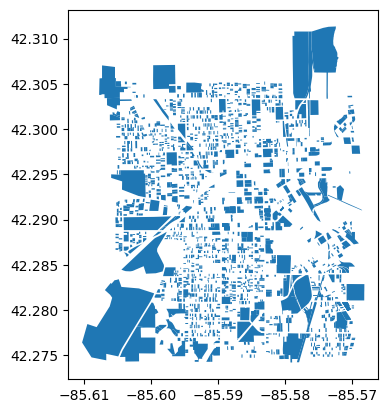

In [18]:
gdf.plot()

In [38]:
bb =  {"type":"Polygon","coordinates":[[[-85.63471820323583,42.31302106492611],[-85.63471820323583,42.26451099625053],[-85.53790900357403,42.26451099625053],[-85.53790900357403,42.31302106492611],[-85.63471820323583,42.31302106492611]]]}
top_left = bb["coordinates"][0][0]
bot_left = bb["coordinates"][0][1]
bot_right = bb["coordinates"][0][2]
top_right = bb["coordinates"][0][3]
xmin, ymin, xmax, ymax = bot_left[0], bot_left[1], top_right[0], top_right[1]
xmin, ymin, xmax, ymax

(-85.63471820323583, 42.26451099625053, -85.53790900357403, 42.31302106492611)

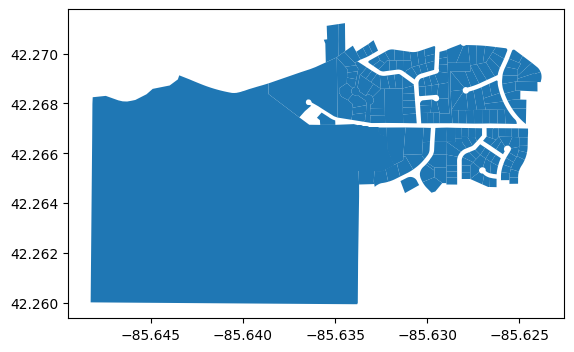

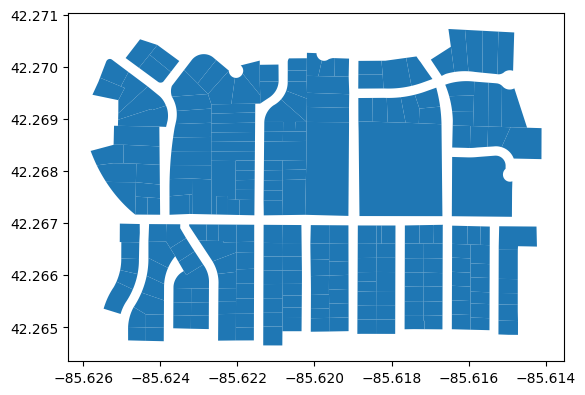

In [40]:
# xmin (min longitude), ymin (min latitude), xmax (max longitude), ymax (max latitude) —
# geometry = [-85.605,42.275,-85.570,42.305]
xmin, ymin, xmax, ymax = -85.635, 42.265, -85.625, 42.270
for r in range(1, 3, 1):
    geom = (f'{xmin},{ymin},{xmax},{ymax}')
    params = f'where=1%3D1&geometryType=esriGeometryEnvelope&inSR=4326&geometry={geom}&outFields=*&returnGeometry=true&f=geojson'
    kzoo_base = 'https://gis.kalamazoocity.org/hosting/rest/services/General_Items/Parcel_Layer/FeatureServer/0/query?' 
    url = (f'{kzoo_base}{params}') 
    gdf = gpd.read_file(url)
    xmin, ymin, xmax, ymax = xmin+.01, ymin, xmax+.01, ymax 
    gdf.plot()